# Classifier Evaluation Assignment

- Complete this Jupyter Notebook.  
- Execute the initial cells and answer the numbered questions.  
- Don't import other libraries.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

results = pd.read_csv('https://raw.githubusercontent.com/msaricaumbc/DS_data/master/ds602/lab-evaluation-data.csv')
results.head()

,actual,prob
0,0.0,0.380052
1,1.0,0.827923
2,1.0,0.929093
3,1.0,0.472508
4,1.0,0.906988


## Data Definitions
- `actual`: Whether the event was true or not. A value of 1.0 is True and 0.0 is False.  
- `prob`: The probability that the event was True. This is estimated from a classification model.

## Question 1
- Determine the distribution of the actual event.
- Would you be concerned about bias due to imbalance?

In [26]:
# insert code here
distribution = results['actual'].value_counts(normalize=True)
print(distribution)


1.0    0.6
0.0    0.4
Name: actual, dtype: float64


Insert comments here

A dataset with 60-40 split is not heavily imbalanced. However, with an imbalanced dataset, there is a risk of bias in the model due to the disproportionate representation of the classes. In particular, the model may be biased towards the majority class (in this case, the "False" class), leading to poor performance on the minority class (in this case, the "True" class).

## Question 2
- Create a histogram that shows the distribution of the probabilities for the True and False classes.  
- Describe what you observe.

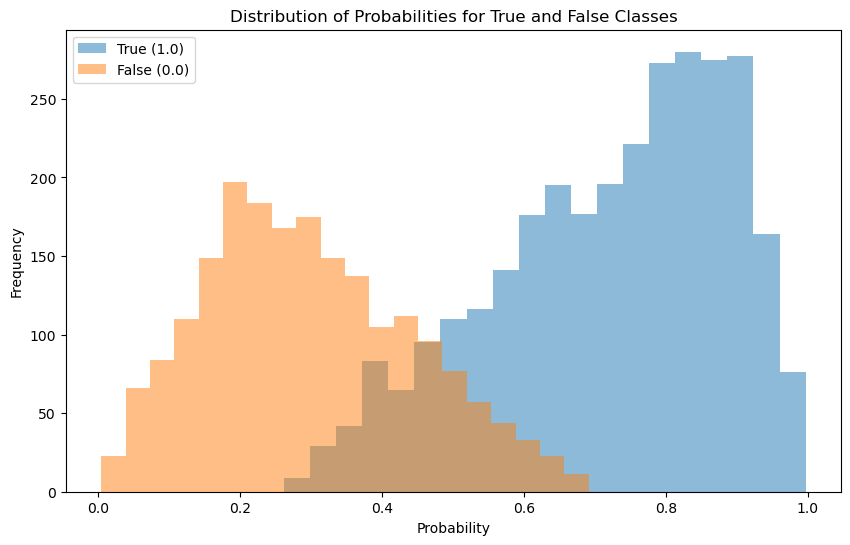

In [27]:
# Filtering data for True and False classes
true_probs = results[results['actual'] == 1.0]['prob']
false_probs = results[results['actual'] == 0.0]['prob']

# Plotting the histograms
plt.figure(figsize=(10, 6))
plt.hist(true_probs, bins=20, alpha=0.5, label='True (1.0)')
plt.hist(false_probs, bins=20, alpha=0.5, label='False (0.0)')
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.title('Distribution of Probabilities for True and False Classes')
plt.legend(loc='best')
plt.show()



The observation that can be made from this histogram is that the model does well in predicting classifying the classes. The plot for positive class is inclined towards right and the plot for negative class is inclined towards left, which supports my first statement. there are some positive examples that the model predicts with < 0.5 probablity and there are some negative classes that the model predicts with probablility greathen than 0.5 but they values are significantly smaller compared to correct predictions.

## Question 3
- Create a simple confusion matrix. Use `0.5` as the threshold for whether an observation should be considered True or False.  
- Comment on what you observe.

In [28]:
# Given data
actual = results['actual']
prob = results['prob']

# Generate predictions based on the 0.5 threshold
predicted = (prob > 0.5).astype(float)

# Manually calculate confusion matrix
TP = sum((actual == 1) & (predicted == 1))
TN = sum((actual == 0) & (predicted == 0))
FP = sum((actual == 0) & (predicted == 1))
FN = sum((actual == 1) & (predicted == 0))

# Create a confusion matrix table
labels = ['False', 'True']
cm_data = [[TN, FP], [FN, TP]]
cm_df = pd.DataFrame(cm_data, columns=['Predicted ' + label for label in labels], index=['Actual ' + label for label in labels])

print(cm_df)


              Predicted False  Predicted True
Actual False             1790             210
Actual True               377            2623


Insert comments here

The model with a threshold 0.5 was able to classifiy majority of positive class into positive and negative to negative. However in some cases the model fails to do so for around 10 to 15 percent inputs.

## Question 4
- Calculate the accuracy, precision, and recall `without` using any pre-built functions.
- Which measure would you use if this was your model and why?

In [29]:
# insert code here

# Calculate accuracy
accuracy = (TP + TN) / (TP + TN + FP + FN)

# Calculate precision
precision = TP / (TP + FP)

# Calculate recall
recall = TP / (TP + FN)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")


Accuracy: 0.8826
Precision: 0.9259
Recall: 0.8743


In this case i would recommend using accuracy because i want the model to perform well on predicting the true and false classes correctly. but the metric to use would vary depending on the company requirement whether they want to prioritize false positives or false negatives, then they can use precision or recall


## Question 5
- Construct a ROC curve plot.  
- Comment on the fit of the model based on this chart.

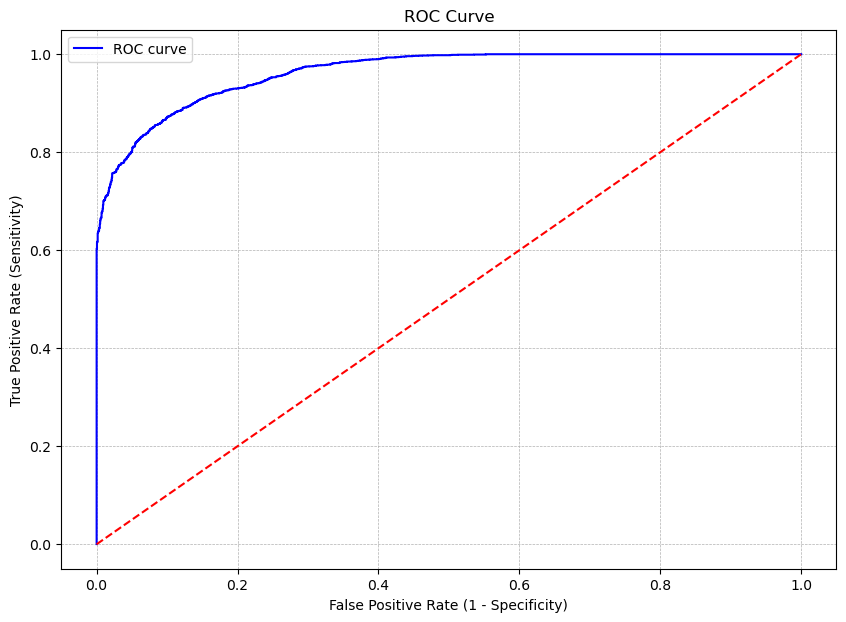

In [30]:
# Insert code here
# Calculate TPR and FPR for various thresholds
fpr, tpr, thresholds = [], [], []
sorted_probs_with_actual = results.sort_values(by='prob', ascending=False)

for threshold in sorted_probs_with_actual['prob']:
    
    predicted = (sorted_probs_with_actual['prob'] >= threshold).astype(float)
    FP = np.sum((sorted_probs_with_actual['actual'] == 0.0) & (predicted == 1.0))
    TP = np.sum((sorted_probs_with_actual['actual'] == 1.0) & (predicted == 1.0))
    TN = np.sum((sorted_probs_with_actual['actual'] == 0.0) & (predicted == 0.0))
    FN = np.sum((sorted_probs_with_actual['actual'] == 1.0) & (predicted == 0.0))
    
    fpr_value = FP / (FP + TN)
    tpr_value = TP / (TP + FN)
    
    fpr.append(fpr_value)
    tpr.append(tpr_value)

# Plot the ROC curve
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='blue', label='ROC curve')
plt.plot([0, 1], [0, 1], linestyle='--', color='red')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()


Insert comments here

Based on the fit, the area under curve looks like covers more than 90 percent, which means the model is predicting very well. The model have good ability to distinguish positive and negative classes